# California Housing — Exploratory Data Analysis & Baseline Model

Analysis of the 1990 California census housing dataset. Each row is a **census block** — a small neighborhood of ~600–3,000 people. The goal is to understand what drives house prices and build a baseline linear regression model.

**Dataset:** 20,640 blocks · 8 features · 1 target (`MedHouseVal`)

| Column | Description | Unit |
|--------|-------------|------|
| `MedInc` | Median household income | Tens of thousands USD |
| `HouseAge` | Median house age in the block | Years (capped at 52) |
| `AveRooms` | Average rooms per household | Rooms |
| `AveBedrms` | Average bedrooms per household | Bedrooms |
| `Population` | Total block population | People |
| `AveOccup` | Average occupants per household | People |
| `Latitude` | Block latitude | Degrees North |
| `Longitude` | Block longitude | Degrees West |
| `MedHouseVal` | **Target** — median house value | Hundreds of thousands USD (capped at 5.0) |

## 1. Setup

In [ ]:
from sklearn.datasets import fetch_california_housing
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

data = fetch_california_housing(as_frame=True)
df = data.frame
df.shape

## 2. Data Overview

In [5]:
df.head(10)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422
5,4.0368,52.0,4.761658,1.103627,413.0,2.139896,37.85,-122.25,2.697
6,3.6591,52.0,4.931907,0.951362,1094.0,2.128405,37.84,-122.25,2.992
7,3.1200,52.0,4.797527,1.061824,1157.0,1.788253,37.84,-122.25,2.414
8,2.0804,42.0,4.294118,1.117647,1206.0,2.026891,37.84,-122.26,2.267
9,3.6912,52.0,4.970588,0.990196,1551.0,2.172269,37.84,-122.25,2.611


In [6]:
print(df.shape)
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

(20640, 9)
MedInc         float64
HouseAge       float64
AveRooms       float64
AveBedrms      float64
Population     float64
AveOccup       float64
Latitude       float64
Longitude      float64
MedHouseVal    float64
dtype: object

Missing values:
MedInc         0
HouseAge       0
AveRooms       0
AveBedrms      0
Population     0
AveOccup       0
Latitude       0
Longitude      0
MedHouseVal    0
dtype: int64


In [7]:
df.describe()
# AveRooms max = 141, AveOccup max = 1243 — math artifacts of blocks with very few households
# HouseAge and MedHouseVal both capped (52 and 5.0) — census collection artifact, not natural data
# No missing values across all 20,640 rows

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 3. Distributions

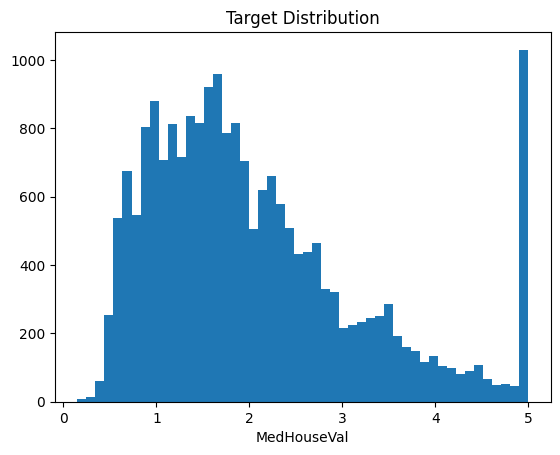

In [8]:
plt.hist(df["MedHouseVal"], bins=50)
plt.xlabel("MedHouseVal")
plt.title("Target Distribution")
plt.show()
# Right-skewed. Large spike at 5.0 — all blocks worth >$500k were recorded as 5.0 (data cap).
# This artificial ceiling will hurt regression models that try to predict expensive houses.

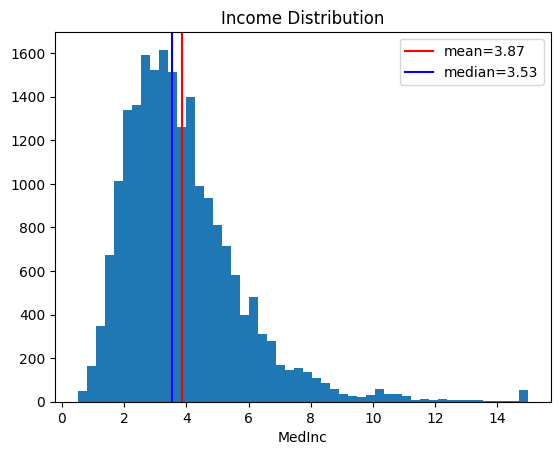

In [9]:
plt.hist(df["MedInc"], bins=50)
plt.axvline(df["MedInc"].mean(), color="red", label=f"mean={df['MedInc'].mean():.2f}")
plt.axvline(df["MedInc"].median(), color="blue", label=f"median={df['MedInc'].median():.2f}")
plt.xlabel("MedInc")
plt.title("Income Distribution")
plt.legend()
plt.show()
# Right-skewed — mean (3.87) > median (3.53). A few high-income blocks pull the mean up.
# Most blocks earn $25k–$50k/yr. Skew suggests log transform before modeling.

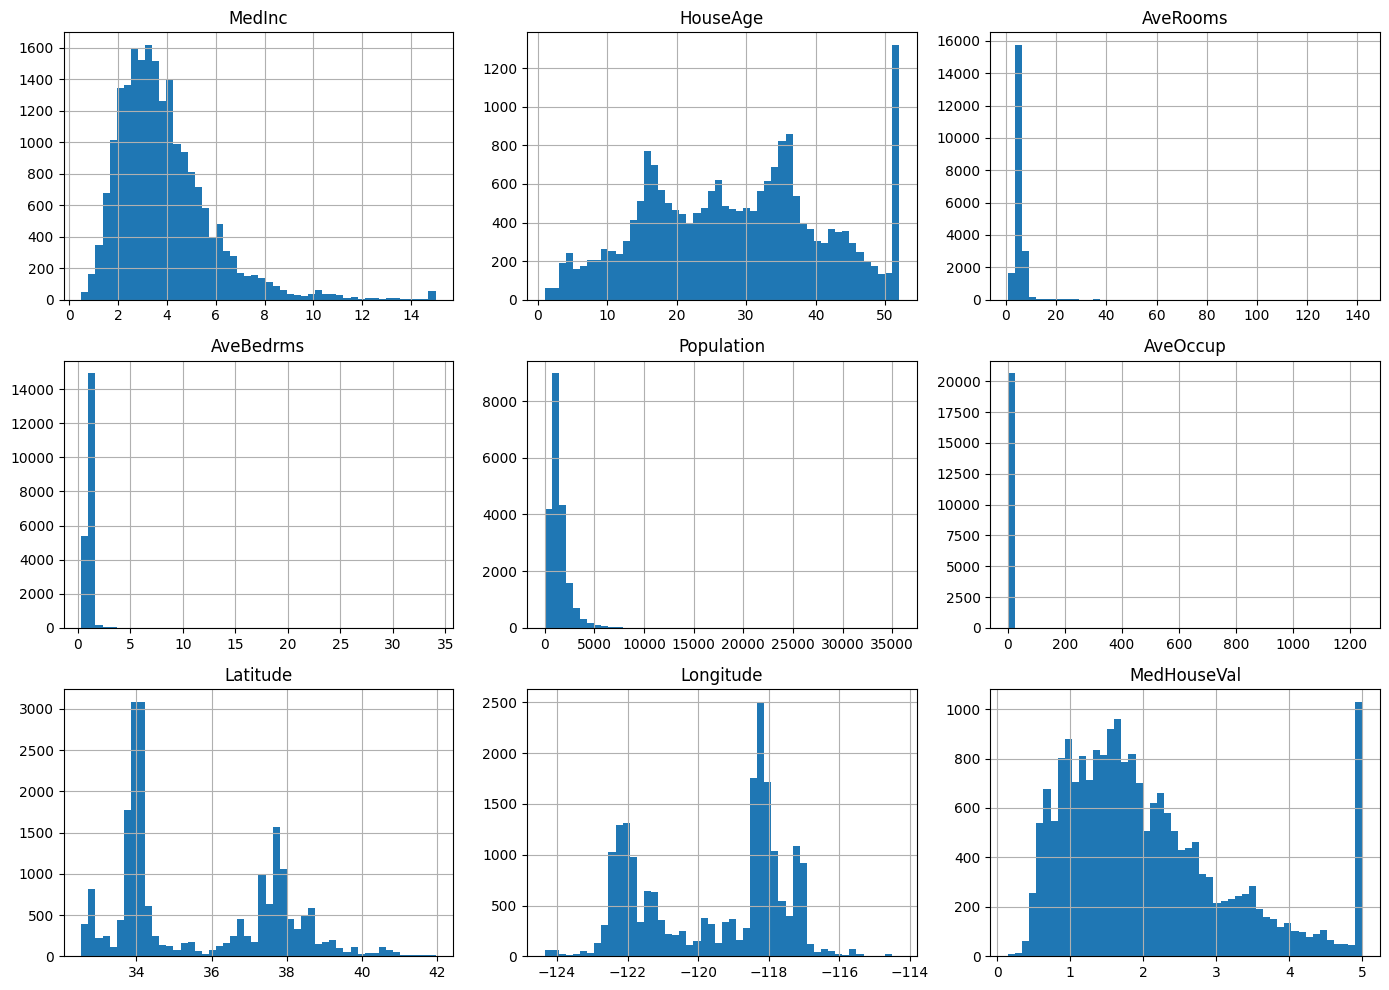

In [10]:
df.hist(bins=50, figsize=(14, 10))
plt.tight_layout()
plt.show()
# Right-skewed: MedInc, AveRooms, AveOccup, Population — candidates for log transform
# Capped distributions: HouseAge (spike at 52), MedHouseVal (spike at 5.0)
# AveOccup x-axis stretched to 1243 by a single outlier block
# Latitude and Longitude — geographic spread, not a statistical distribution

In [11]:
outliers = df[(df["AveRooms"] > 50) | (df["AveOccup"] > 20)]
print(f"{len(outliers)} outlier blocks ({len(outliers)/len(df)*100:.2f}% of data)")
outliers[["AveRooms", "AveOccup", "Population"]].describe()
# Caused by blocks with very few households — dividing 300 total rooms by 2 households gives AveRooms=150
# Less than 0.1% of data — kept in, minimal model impact

19 outlier blocks (0.09% of data)


,AveRooms,AveOccup,Population
count,19.000000,19.000000,19.000000
mean,38.526065,152.108667,2311.210526
std,42.508695,315.202893,2946.459770
min,3.166667,1.729730,28.000000
25%,5.312745,2.333333,73.500000
50%,9.076923,21.333333,1154.000000
75%,58.072115,73.460714,3542.000000
max,141.909091,1243.333333,8733.000000


## 4. Feature–Target Relationships

In [12]:
df.corr()["MedHouseVal"].sort_values()
# MedInc is the strongest predictor (0.69) — income drives house prices
# Latitude most negatively correlated (-0.14) — further north = cheaper on average
# AveBedrms, Population, AveOccup near zero — weak on their own but still included in the model

Latitude      -0.144160
AveBedrms     -0.046701
Longitude     -0.045967
Population    -0.024650
AveOccup      -0.023737
HouseAge       0.105623
AveRooms       0.151948
MedInc         0.688075
MedHouseVal    1.000000
Name: MedHouseVal, dtype: float64

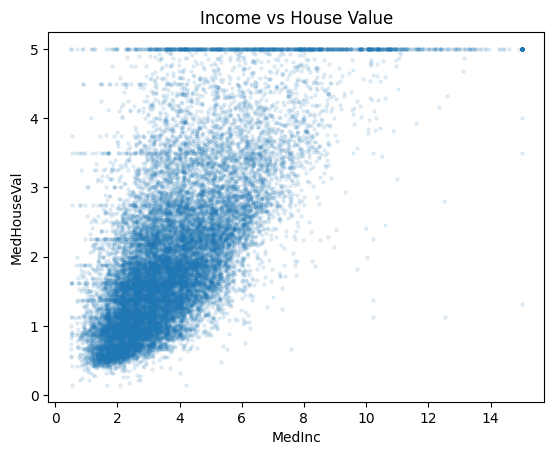

In [13]:
plt.scatter(df["MedInc"], df["MedHouseVal"], alpha=0.1, s=5)
plt.xlabel("MedInc")
plt.ylabel("MedHouseVal")
plt.title("Income vs House Value")
plt.show()
# Broadly linear but with spread — higher income areas have higher house values.
# Flat band at MedHouseVal=5.0 confirms the data cap affecting high-value blocks.

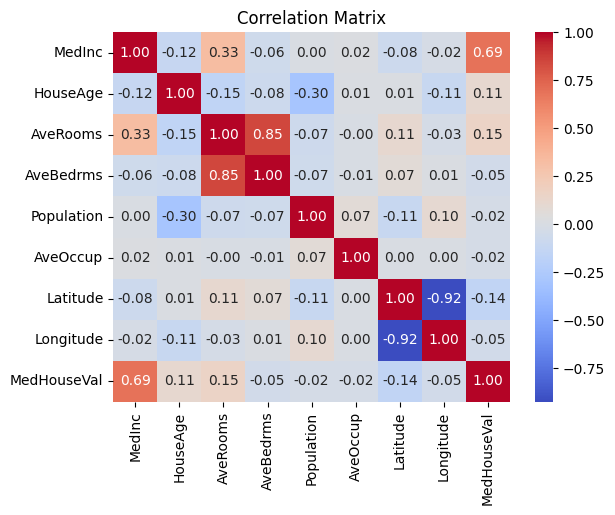

In [14]:
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()
# MedInc has the strongest correlation with MedHouseVal (0.69)
# AveRooms and AveBedrms are highly correlated with each other (0.85) — multicollinearity
# For linear regression, this makes it hard to isolate each feature's individual effect

## 5. Geographic Analysis

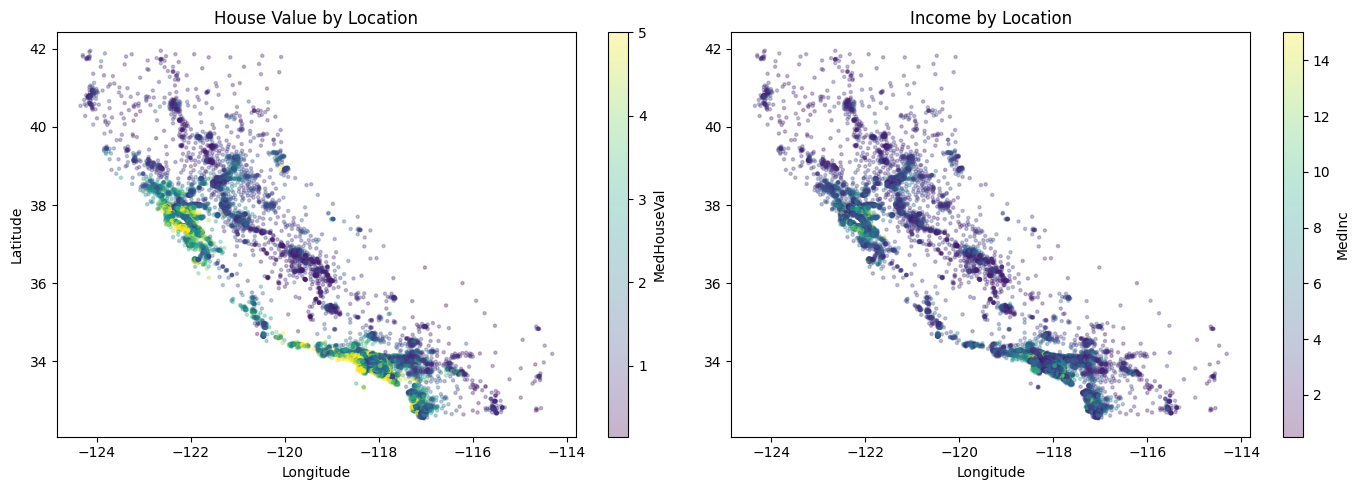

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sc1 = axes[0].scatter(df["Longitude"], df["Latitude"], c=df["MedHouseVal"], cmap="viridis", alpha=0.3, s=5)
plt.colorbar(sc1, ax=axes[0], label="MedHouseVal")
axes[0].set_title("House Value by Location")
axes[0].set_xlabel("Longitude")
axes[0].set_ylabel("Latitude")

sc2 = axes[1].scatter(df["Longitude"], df["Latitude"], c=df["MedInc"], cmap="viridis", alpha=0.3, s=5)
plt.colorbar(sc2, ax=axes[1], label="MedInc")
axes[1].set_title("Income by Location")
axes[1].set_xlabel("Longitude")

plt.tight_layout()
plt.show()
# California's shape is clearly visible from the dot pattern
# Most expensive blocks (yellow) cluster around SF Bay Area and coastal LA — matches real life
# Income map closely mirrors the house value map — geography and income are linked

## 6. Baseline Linear Regression Model

**Pre-modeling decisions from EDA:**
- Log-transform `MedInc`, `AveRooms`, `AveOccup`, `Population` — all right-skewed with outliers
- Log-transform target `MedHouseVal` — right-skewed, proportional relationship with income
- Use all 8 features — geography and income strong, others add marginal signal
- Evaluate R² in log scale — model is trained and optimised in log space

In [16]:
data = fetch_california_housing(as_frame=True)
df_model = data.frame

for col in ["MedInc", "AveRooms", "AveOccup", "Population"]:
    df_model[col] = np.log(df_model[col])

X = df_model.drop(columns=["MedHouseVal"])
y = np.log(df_model["MedHouseVal"])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

model = LinearRegression()
model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

print(f"R\u00b2   : {r2_score(y_test, y_pred):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred)):.4f}")

R²   : 0.6467
RMSE : 0.3386


Coefficients (by magnitude):
  Latitude      -0.5635
  Longitude     -0.5151
  MedInc        +0.3682
  AveOccup      -0.1157
  AveBedrms     +0.0668
  AveRooms      -0.0593
  HouseAge      +0.0411
  Population    +0.0167


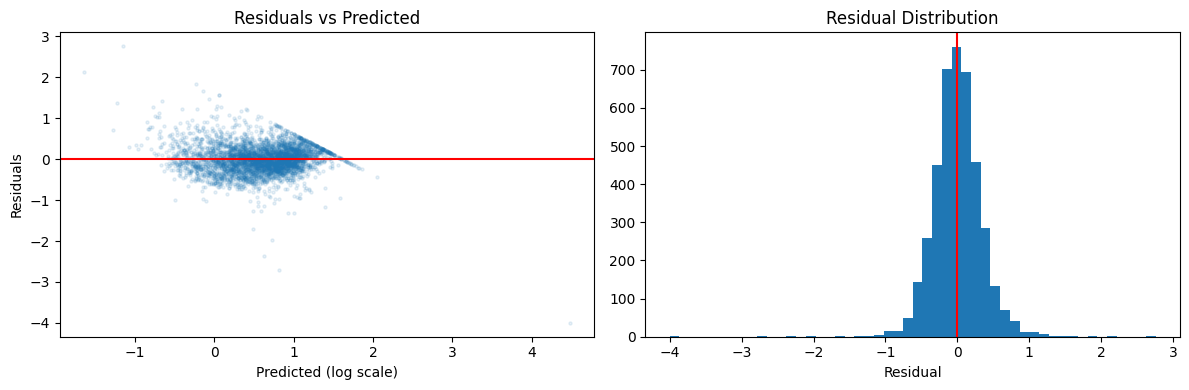

In [17]:
print("Coefficients (by magnitude):")
for k, v in sorted(zip(X.columns, model.coef_), key=lambda x: abs(x[1]), reverse=True):
    print(f"  {k:12s}  {v:+.4f}")

residuals = y_test - y_pred

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred, residuals, alpha=0.1, s=5)
axes[0].axhline(0, color="red")
axes[0].set_xlabel("Predicted (log scale)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals, bins=50)
axes[1].axvline(0, color="red")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()
# Residuals roughly centered at 0 — no systematic bias after log transform
# Fan shape persists — model less accurate for high-value blocks
# Linear regression has reached its ceiling; a tree-based model would reduce the fan shape

## 7. Random Forest Model

Linear regression explained 65% of variance but showed a fan-shaped residual pattern — evidence of non-linear relationships it couldn't capture. Random Forest handles non-linearity naturally by combining 100 decision trees.

**Same transforms and split as the linear model — only the model changes.**

In [ ]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)
y_pred_rf = rf.predict(X_test_scaled)

print(f"R²   : {r2_score(y_test, y_pred_rf):.4f}")
print(f"RMSE : {np.sqrt(mean_squared_error(y_test, y_pred_rf)):.4f}")

In [ ]:
print("Feature Importances (by magnitude):")
for k, v in sorted(zip(X.columns, rf.feature_importances_), key=lambda x: x[1], reverse=True):
    print(f"  {k:12s}  {v:.4f}")

residuals_rf = y_test - y_pred_rf

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_rf, residuals_rf, alpha=0.1, s=5)
axes[0].axhline(0, color="red")
axes[0].set_xlabel("Predicted (log scale)")
axes[0].set_ylabel("Residuals")
axes[0].set_title("Residuals vs Predicted")

axes[1].hist(residuals_rf, bins=50)
axes[1].axvline(0, color="red")
axes[1].set_xlabel("Residual")
axes[1].set_title("Residual Distribution")

plt.tight_layout()
plt.show()
# MedInc accounts for ~50% of feature importance — matches EDA correlation findings
# Longitude + Latitude together ~24% — location is the second biggest driver
# Residuals centered at 0 with no pattern — fan shape gone compared to linear regression